In [1]:
import sys
import os
sys.path.append("../")
print(os.getcwd())
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import os
from datetime import datetime
from src.model import VAE  

latent_dim = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae_model_path = "../saved_models/vae20250408_230217_vae.pth"
vae = VAE(latent_dim=latent_dim).to(device)  

checkpoint = torch.load(vae_model_path, map_location=device)
vae.load_state_dict(checkpoint['model_state_dict'])
vae.eval()   



/mnt/batch/tasks/shared/LS_root/mounts/clusters/jack-vm/code/Projects/Jack_ForceDeck_Winter_2024/countermovement-jump-analysis/scripts


/tmp/ipykernel_3148/98384764.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(vae_model_path, map_location=device)


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
  )
  (mean_layer): Linear(in_features=64, out_features=4, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=4, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=100, bias=True)
  )
)

In [2]:
# path = r""
data = pd.read_pickle("../../Cleaned Code/expandeddataframe.pkl")  
pd.set_option("display.max_columns", None)

In [3]:
data = data[data["Team"] == "Softball"]

In [4]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight
22062,0,0,bd789c38-b918-47fd-8b89-eea1ea012416,1,706fdedc-d845-447c-b5e4-1ebe99cec84d,2022-03-14 15:06:53.496000+00:00,Softball,Sport,NaN,NaN,NaN,9.818,10.194,10.004,10.064,17.800435,9.818,12.949611,12.113446,0.518,32.891994,30.774761,30.768136,69.694,result\nPOSITIVE_IMPULSE 471.048550\nPOSITI...,3626.631708,159.572,result\nLANDING_RFD 119287.150\nLANDING_RFD...,2.555,436.402,-0.115,69.694,result\nPEAK_LANDING_FORCE 5248.634598\nPEA...,10857.56,0.541,79.500676,result\nLANDING_IMPULSE 68.865922\nLANDING_...,88980.0,result\nMEAN_ECCENTRIC_FORCE 650.179571\nME...,419.362148,6.352047,136.162885,result\nECCENTRIC_BRAKING_IMPULSE 63.707917...,982.134598,1327.55884,result\nECCENTRIC_BRAKING_RFD 8989.473684\

In [5]:
def find_jump_end_index(sequence, threshold=0):
    """Finds the index of the last non-zero value before flatline."""
    nonzero_indices = (np.abs(sequence) > threshold).nonzero()[0]
    return nonzero_indices[-1] if len(nonzero_indices) > 0 else len(sequence) - 1

def get_jump_end_time(row):
    force_seq = np.array(row["normalized_time_series"])
    end_idx = find_jump_end_index(force_seq)
    return (end_idx / 1000)
data["jump_end_time"] = data.apply(get_jump_end_time, axis=1)


In [6]:
data = data[data["outlier"] == 0]
rep_counts = data.groupby("testID")["profileID"].count()
low_rep_testIDs = rep_counts[rep_counts < 2].index
data.loc[data["testID"].isin(low_rep_testIDs), "outlier"] = 1
data["outlier"] = (data["JUMP_HEIGHT_INCHES"] < 5).astype(int)

# Existing high-start mask
high_start_mask = data["downsampled_time_series"].apply(lambda x: np.any(np.array(x[20:31]) > 1))

# New low-in-air mask
low_air_mask = data["downsampled_time_series"].apply(lambda x: np.any(np.array(x[60:81]) < 1.6))

# Apply both conditions
data.loc[high_start_mask | low_air_mask, "outlier"] = 1

# Clean final dataset
data_clean = data[data["outlier"] == 0].copy()
data = data_clean


In [7]:
downsampled_data = data['downsampled_time_series'].values

downsampled_tensor = torch.tensor(downsampled_data.tolist(), dtype=torch.float32).to(device)

In [8]:
def get_latent_stats(vae, data_tensor):
    vae.eval()
    with torch.no_grad():
        mean, logvar = vae.encode(data_tensor)
        std = torch.exp(0.5 * logvar)
        z = vae.reparameterization(mean, std)
    return mean.cpu().numpy(), std.cpu().numpy(), z.cpu().numpy()


In [9]:
means, stds, latents = get_latent_stats(vae, downsampled_tensor)

In [10]:
data["vae_latent_space_4d"] = list(means)

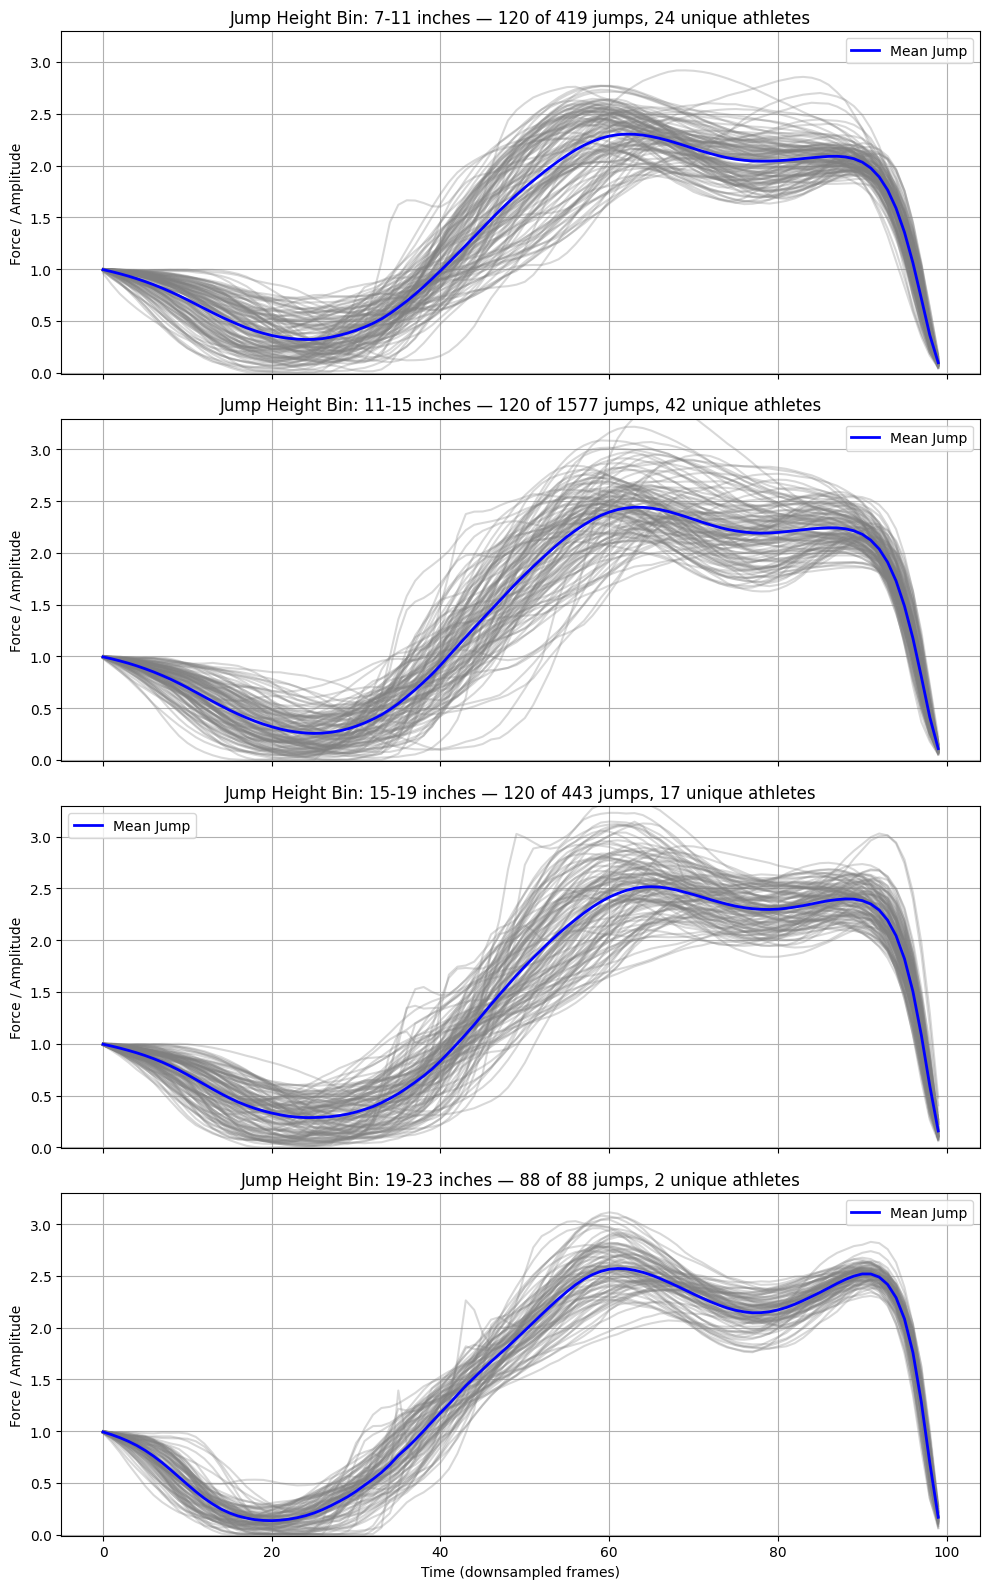

In [11]:
import math
from pandas.api.types import CategoricalDtype

BIN_SIZE = 4  # inches per bin
MAX_JUMPS_PER_BIN = 120  # max jumps to sample per bin

# Filter and bin
binned_data = data.dropna(subset=["JUMP_HEIGHT_INCHES", "downsampled_time_series"])
binned_data = binned_data[binned_data["JUMP_HEIGHT_INCHES"] > 6]

min_height = math.floor(binned_data["JUMP_HEIGHT_INCHES"].min())
max_height = math.ceil(binned_data["JUMP_HEIGHT_INCHES"].max())
bins = np.arange(min_height, max_height + BIN_SIZE, BIN_SIZE)
bin_labels = [f"{int(b)}-{int(b + BIN_SIZE)}" for b in bins[:-1]]

binned_data["jump_bin"] = pd.cut(
    binned_data["JUMP_HEIGHT_INCHES"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)
cat_type = CategoricalDtype(categories=bin_labels, ordered=True)
binned_data["jump_bin"] = binned_data["jump_bin"].astype(cat_type)

unique_bins = sorted(binned_data["jump_bin"].dropna().unique(), key=lambda x: bin_labels.index(str(x)))
n_bins = len(unique_bins)

# Step 1: Determine global y-limits
y_min, y_max = np.inf, -np.inf
for bin_label in unique_bins:
    group = binned_data[binned_data["jump_bin"] == bin_label]
    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)))
    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        y_min = min(y_min, jump_matrix.min())
        y_max = max(y_max, jump_matrix.max())
    except Exception as e:
        print(f"Error computing global y-limits for bin {bin_label}: {e}")

# Step 2: Plot with consistent y-axis
fig, axes = plt.subplots(n_bins, 1, figsize=(10, 4 * n_bins), sharex=True)
if n_bins == 1:
    axes = [axes]  

for ax, bin_label in zip(axes, unique_bins):
    group = binned_data[binned_data["jump_bin"] == bin_label]
    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)))  

    for _, row in group_sample.iterrows():
        ax.plot(row["downsampled_time_series"], color='gray', alpha=0.3)

    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        mean_jump = jump_matrix.mean(axis=0)
        ax.plot(mean_jump, color='blue', linewidth=2, label='Mean Jump')
    except Exception as e:
        print(f"Skipping mean plot for bin {bin_label}: {e}")

    unique_athletes = group["profileID"].nunique()
    ax.set_title(
        f"Jump Height Bin: {bin_label} inches — "
        f"{len(group_sample)} of {len(group)} jumps, "
        f"{unique_athletes} unique athletes"
    )
    ax.set_ylabel("Force / Amplitude")
    ax.set_ylim(y_min, y_max)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (downsampled frames)")
plt.tight_layout()
plt.show()


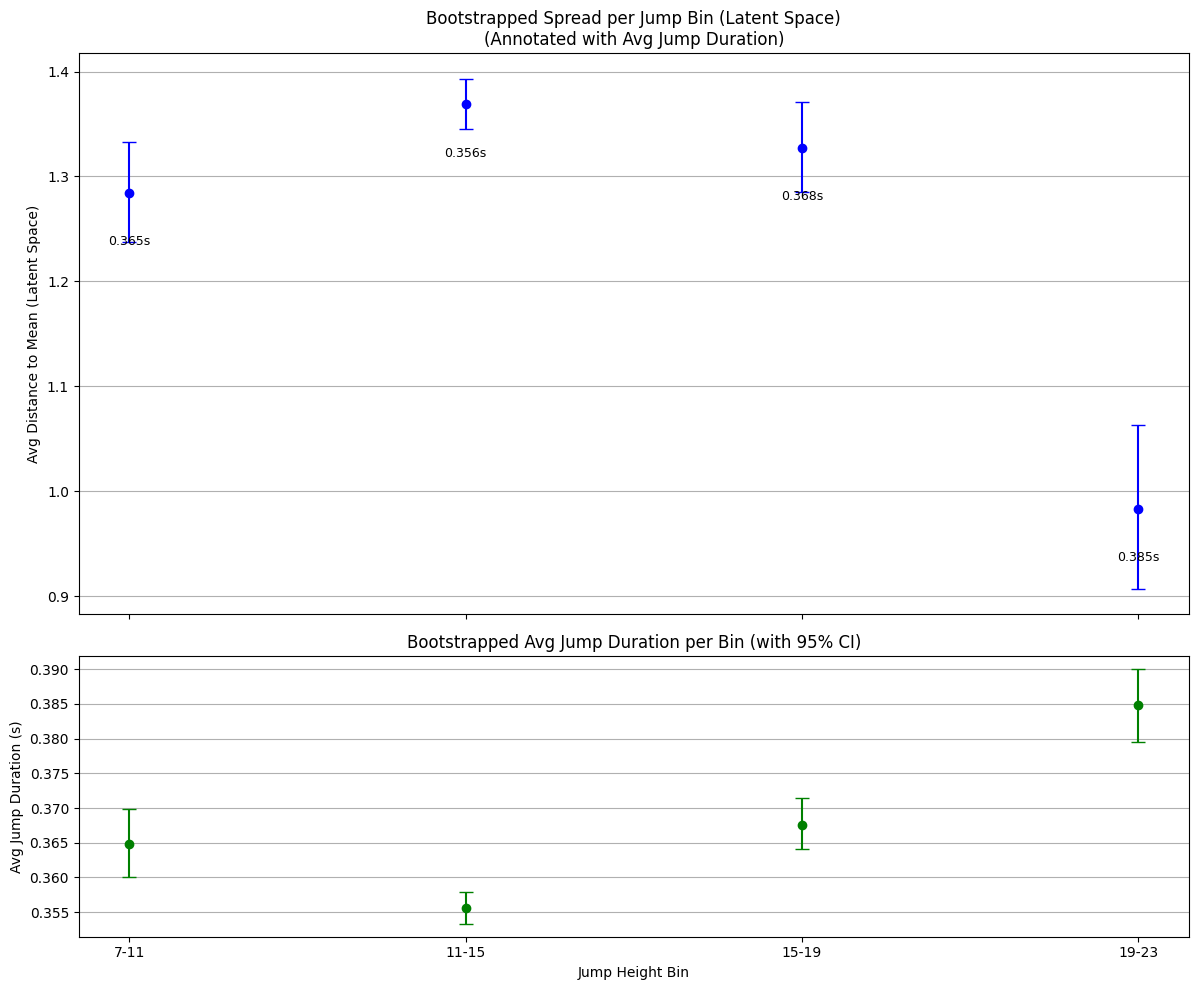

In [12]:
n_bootstrap = 1000
means = []
ci_lowers = []
ci_uppers = []
labels = []
sample_means = []

jump_end_means = []
jump_end_ci_lowers = []
jump_end_ci_uppers = []

for idx, bin_label in enumerate(bin_labels):
    group = binned_data[binned_data["jump_bin"] == bin_label]

    if group.empty:
        continue
    sample_means.append(group["vae_latent_space_4d"].mean())

    latent_matrix = np.stack(group["vae_latent_space_4d"].values)
    n_total = latent_matrix.shape[0]
    jump_end_array = group["jump_end_time"].values
    
    # sample_means.append(latent_matrix.mean())

    bootstrap_spreads = []
    for _ in range(n_bootstrap):
        sampled_indices = np.random.choice(n_total, size=n_total, replace=True)
        sample = latent_matrix[sampled_indices]
        sample_mean = sample.mean(axis=0)
        distances = np.linalg.norm(sample - sample_mean, axis=1)
        bootstrap_spreads.append(distances.mean())

    means.append(np.mean(bootstrap_spreads))
    ci_lowers.append(np.percentile(bootstrap_spreads, 2.5))
    ci_uppers.append(np.percentile(bootstrap_spreads, 97.5))
    labels.append(bin_label)

    jump_end_boots = []
    for _ in range(n_bootstrap):
        sampled = np.random.choice(jump_end_array, size=n_total, replace=True)
        jump_end_boots.append(sampled.mean())

    jump_end_means.append(np.mean(jump_end_boots))
    jump_end_ci_lowers.append(np.percentile(jump_end_boots, 2.5))
    jump_end_ci_uppers.append(np.percentile(jump_end_boots, 97.5))
    
    
# fig, ax1 = plt.subplots(figsize=(12, 6))

# ax1.errorbar(labels, means,
#              yerr=[np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)],
#              fmt='o', capsize=5, linestyle='None', color='b')

# for i, avg_end in enumerate(jump_end_means):
#     ax1.text(i, means[i] - 0.05, f"{avg_end:.3f}s", ha='center', fontsize=9, color='black')

# ax1.set_ylabel("Avg Distance to Mean (Latent Space)")
# ax1.set_title("Bootstrapped Spread per Jump Bin (Latent Space)\n(Annotated with Avg Jump Duration)")
# ax1.grid(True, axis='y')

# plt.tight_layout()
# plt.savefig("bootstrapstuff.png", dpi=300)
# plt.show()


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.errorbar(labels, means,
             yerr=[np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)],
             fmt='o', capsize=5, linestyle='None', color='b')

for i, avg_end in enumerate(jump_end_means):
    ax1.text(i, means[i] - 0.05, f"{avg_end:.3f}s", ha='center', fontsize=9, color='black')

ax1.set_ylabel("Avg Distance to Mean (Latent Space)")
ax1.set_title("Bootstrapped Spread per Jump Bin (Latent Space)\n(Annotated with Avg Jump Duration)")
ax1.grid(True, axis='y')

ax2.errorbar(labels, jump_end_means,
             yerr=[np.array(jump_end_means) - np.array(jump_end_ci_lowers),
                   np.array(jump_end_ci_uppers) - np.array(jump_end_means)],
             fmt='o', capsize=5, linestyle='None', color='green')

ax2.set_ylabel("Avg Jump Duration (s)")
ax2.set_xlabel("Jump Height Bin")
ax2.set_title("Bootstrapped Avg Jump Duration per Bin (with 95% CI)")
ax2.grid(True, axis='y')
plt.tight_layout()
plt.show()


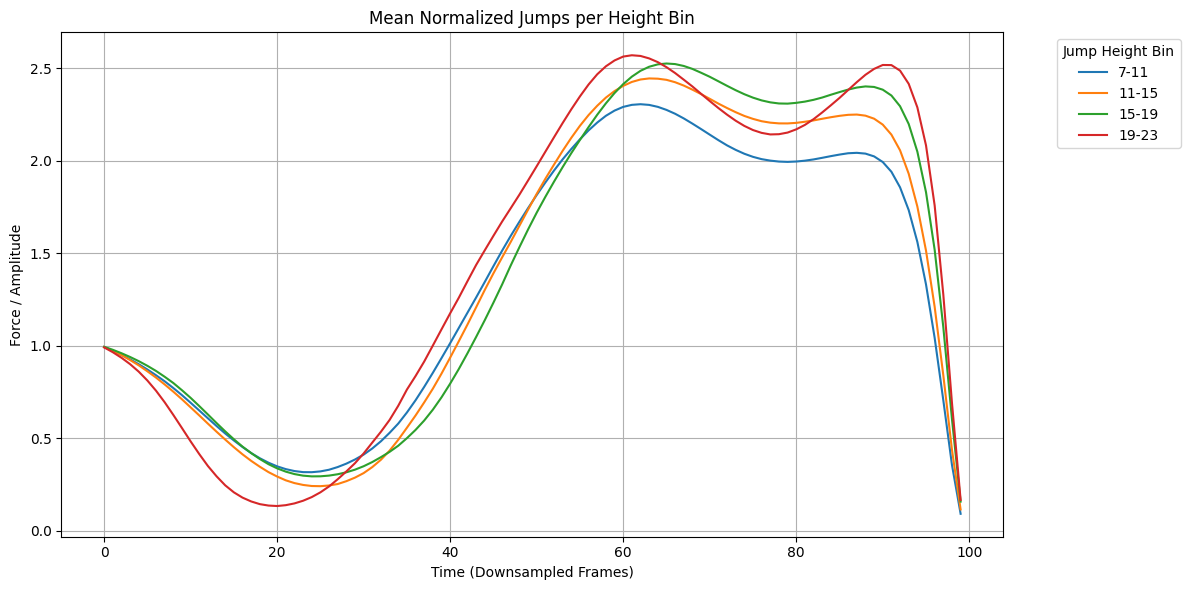

In [13]:
import matplotlib.pyplot as plt

BIN_SIZE = 4
MAX_JUMPS_PER_BIN = 120

fig, ax = plt.subplots(figsize=(12, 6))

for bin_label in bin_labels:
    group = binned_data[binned_data["jump_bin"] == bin_label]
    if group.empty:
        continue

    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)), random_state=42)

    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        mean_jump = jump_matrix.mean(axis=0)
        ax.plot(mean_jump, label=str(bin_label))
    except Exception as e:
        print(f"Skipping {bin_label}: {e}")

ax.set_title("Mean Normalized Jumps per Height Bin")
ax.set_xlabel("Time (Downsampled Frames)")
ax.set_ylabel("Force / Amplitude")
ax.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()


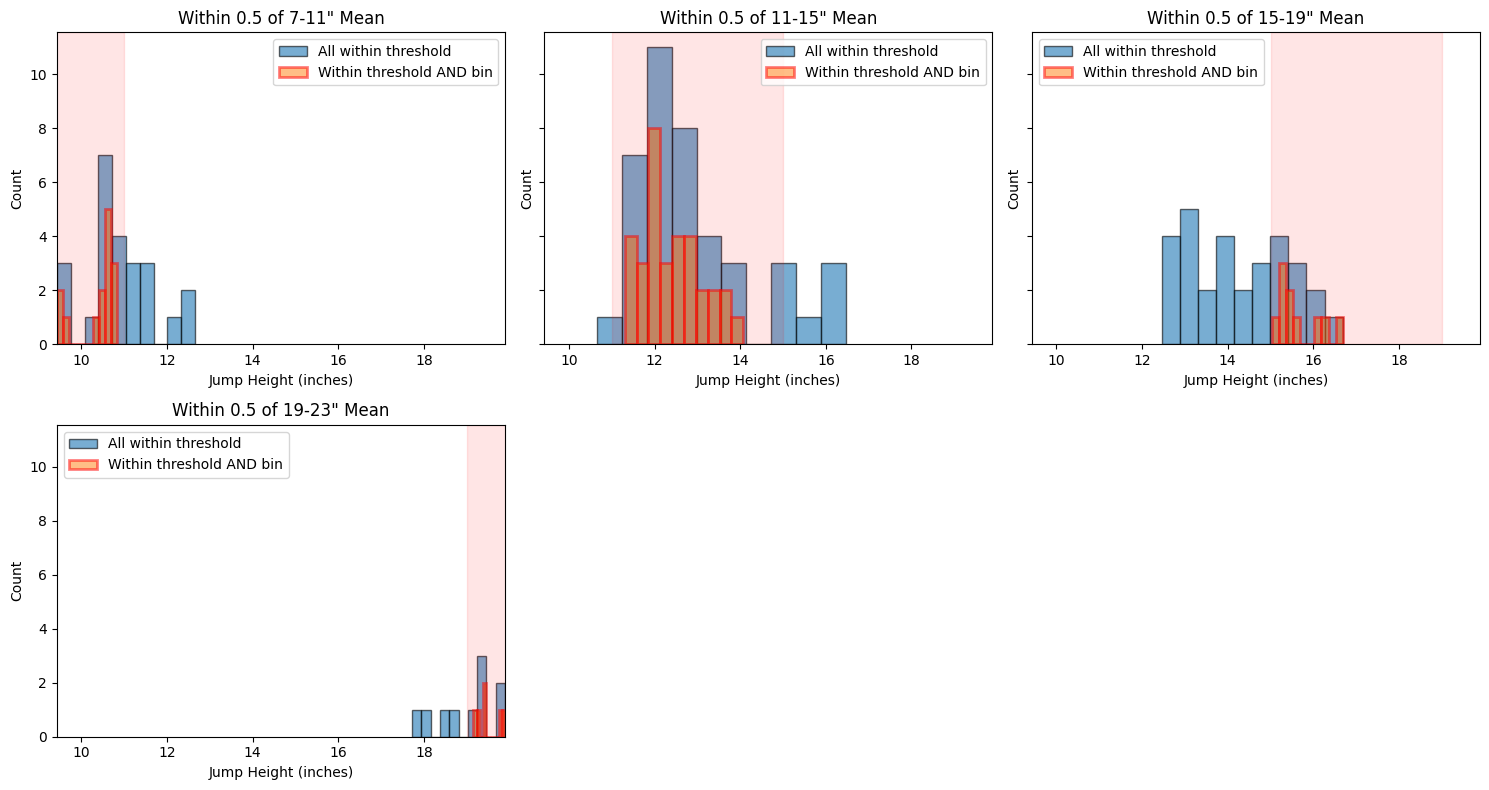

In [14]:
from collections import defaultdict

distance_threshold = 0.5

closest_heights_per_bin = defaultdict(list)
overlapping_heights_per_bin = defaultdict(list)

all_latents = np.stack(binned_data["vae_latent_space_4d"].values)
all_heights = binned_data["JUMP_HEIGHT_INCHES"].values
all_bins = binned_data["jump_bin"].values

# Group jumps by bin
for bin_label in sorted(binned_data["jump_bin"].unique(), key=lambda x: int(x.split('-')[0])):
    group = binned_data[binned_data["jump_bin"] == bin_label]
    if group.empty:
        continue

    bin_latents = np.stack(group["vae_latent_space_4d"].values)
    mean_vector = bin_latents.mean(axis=0)

    distances = np.linalg.norm(all_latents - mean_vector, axis=1)
    within_threshold = distances < distance_threshold

    closest_heights_per_bin[bin_label] = all_heights[within_threshold]

    mask_in_bin = all_bins == bin_label
    overlap_mask = within_threshold & mask_in_bin
    overlapping_heights_per_bin[bin_label] = all_heights[overlap_mask]

# Determine overall plot limits
all_closest_heights = np.concatenate(list(closest_heights_per_bin.values()))
x_min, x_max = all_closest_heights.min(), all_closest_heights.max()

# Setup subplots
n_bins = len(closest_heights_per_bin)
ncols = 3
nrows = int(np.ceil(n_bins / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharey=True)
axs = axs.flatten()

# Iterate over the bins and plot histograms
for i, bin_label in enumerate(closest_heights_per_bin):
    heights = closest_heights_per_bin[bin_label]
    overlapping_heights = overlapping_heights_per_bin[bin_label]

    # Plot all heights within the distance threshold
    axs[i].hist(heights, bins=10, edgecolor='black', alpha=0.6, label='All within threshold')
    
    # Plot overlapping heights (within threshold and bin)
    if len(overlapping_heights) > 0:
        axs[i].hist(overlapping_heights, bins=10, edgecolor='red', alpha=0.5, linewidth=2, label='Within threshold AND bin')

    # Parse the bin_label to get the range to shade
    try:
        bin_start, bin_end = map(int, bin_label.split('-'))
        axs[i].axvspan(bin_start, bin_end, color='red', alpha=0.1)  # Shade the range for the current bin
    except ValueError:
        pass  # Handle case if bin_label is not in expected format

    # Set title, labels, and axis limits
    axs[i].set_title(f'Within {distance_threshold} of {bin_label}" Mean')
    axs[i].set_xlabel("Jump Height (inches)")
    axs[i].set_ylabel("Count")
    axs[i].set_xlim(x_min, x_max)
    axs[i].legend()

# Remove any extra subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


Average Jump End Time for 19-23 bin: 0.38

Outliers with jump end times:
Empty DataFrame
Columns: [JUMP_HEIGHT_INCHES, jump_bin, jump_end_time]
Index: []

Average jump height for all jumps within 0.5 of '19-23' mean (i.e. the ones plotted): 19.00 inches


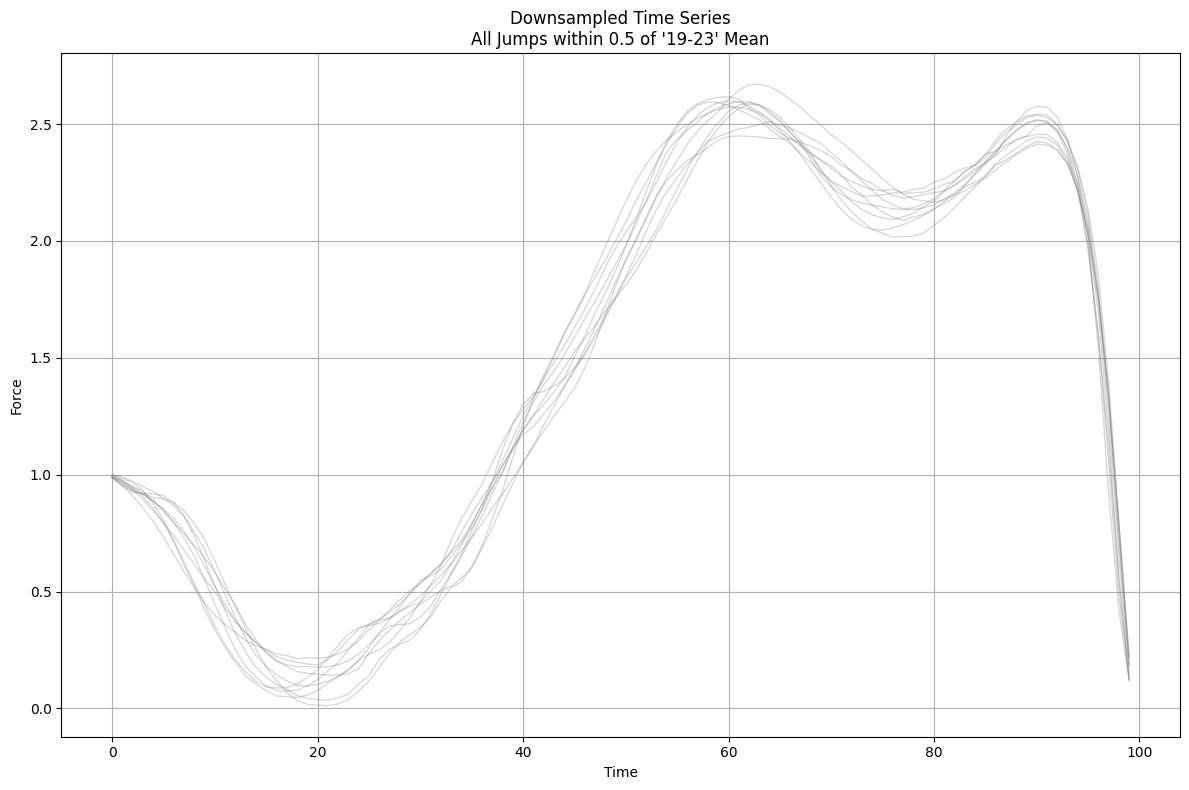

10


In [15]:
from scipy.spatial.distance import euclidean

target_bin = "19-23"
suspicious_height_threshold = 13  

group = binned_data[binned_data["jump_bin"] == target_bin]

average_jump_end_time = group["jump_end_time"].mean()
print(f"Average Jump End Time for {target_bin} bin: {average_jump_end_time:.2f}")

bin_latents = np.stack(group["vae_latent_space_4d"].values)
mean_vector = bin_latents.mean(axis=0)

distances = np.array([euclidean(vec, mean_vector) for vec in all_latents])

within_threshold = distances < distance_threshold
mask_in_bin = all_bins == target_bin
overlap_mask = within_threshold & mask_in_bin

suspicious_mask = within_threshold & (all_heights < suspicious_height_threshold)
suspicious_indices = np.where(suspicious_mask)[0]

outlier_info = binned_data.iloc[suspicious_indices][["JUMP_HEIGHT_INCHES", "jump_bin", "jump_end_time"]]
print("\nOutliers with jump end times:")
print(outlier_info)

plotted_heights = all_heights[within_threshold]
average_plotted_height = plotted_heights.mean()

print(f"\nAverage jump height for all jumps within {distance_threshold} of '{target_bin}' mean (i.e. the ones plotted): {average_plotted_height:.2f} inches")

plt.figure(figsize=(12, 8))

for idx, height in zip(np.where(within_threshold)[0], all_heights[np.where(within_threshold)[0]]):
    time_series = binned_data.iloc[idx]["downsampled_time_series"]
    
    if height < 13:
        plt.plot(time_series, color='red', linewidth=2.5, alpha=0.9)
    else:
        plt.plot(time_series, color='gray', linewidth=1, alpha=0.3)

plt.title(f"Downsampled Time Series\nAll Jumps within {distance_threshold} of '{target_bin}' Mean")
plt.xlabel("Time")
plt.ylabel("Force")
plt.grid(True)

plt.tight_layout()
plt.show()
print(len(plotted_heights))